In [14]:
import pandas as pd

df = pd.read_csv(r"C:\Sem-3 ML\Day14\breast-cancer.csv")

print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [15]:
numeric_data = df.select_dtypes(include="number").drop(columns=["id"])

print(numeric_data.head())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

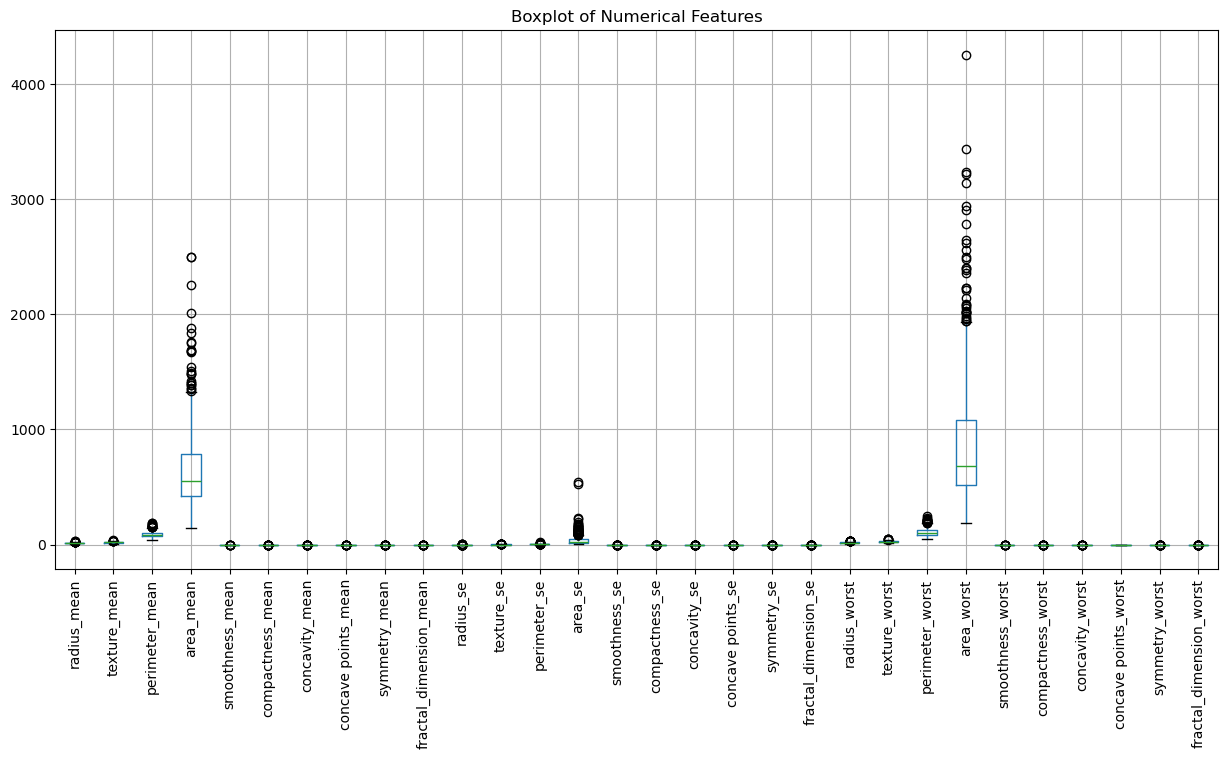

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

numeric_data.boxplot()

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_data)

print(scaled_data)

[[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]


In [18]:
import numpy as np

print("Mean:", scaled_data.mean(axis=0))
print("Standard Deviation:", scaled_data.std(axis=0))

Mean: [-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16  1.87313551e-16  4.99502802e-17 -4.99502802e-17
  1.74825981e-16  4.74527662e-16  2.37263831e-16 -1.12388130e-16
 -1.12388130e-16 -1.31119486e-16 -1.52972733e-16  1.74825981e-16
  1.62338411e-16  0.00000000e+00  8.74129903e-17 -6.24378502e-18
 -8.24179623e-16  1.24875700e-17 -3.74627101e-16  0.00000000e+00
 -2.37263831e-16 -3.37164391e-16  7.49254203e-17  2.24776261e-16
  2.62238971e-16 -5.74428222e-16]
Standard Deviation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [19]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=numeric_data.columns
)

print(scaled_df.head())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [20]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [21]:
y = y.map({"M": 1, "B": 0})

print(y.head())

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

c:\Users\pawan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1]


In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy %:", accuracy * 100)

Accuracy: 0.956140350877193
Accuracy %: 95.6140350877193


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[70  1]
 [ 4 39]]


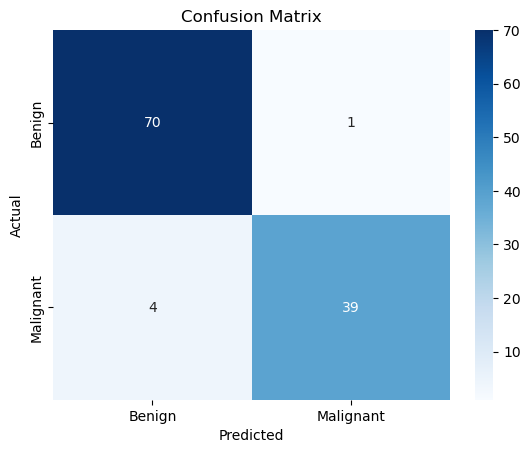

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        71
   Malignant       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [30]:
dt_pred = dt_model.predict(X_test)

print(dt_pred)

[0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 1 0 1
 0 0 1]


In [31]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Accuracy %:", dt_accuracy * 100)

Decision Tree Accuracy: 0.9473684210526315
Accuracy %: 94.73684210526315


In [32]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[68  3]
 [ 3 40]]


In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    dt_pred,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        71
   Malignant       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



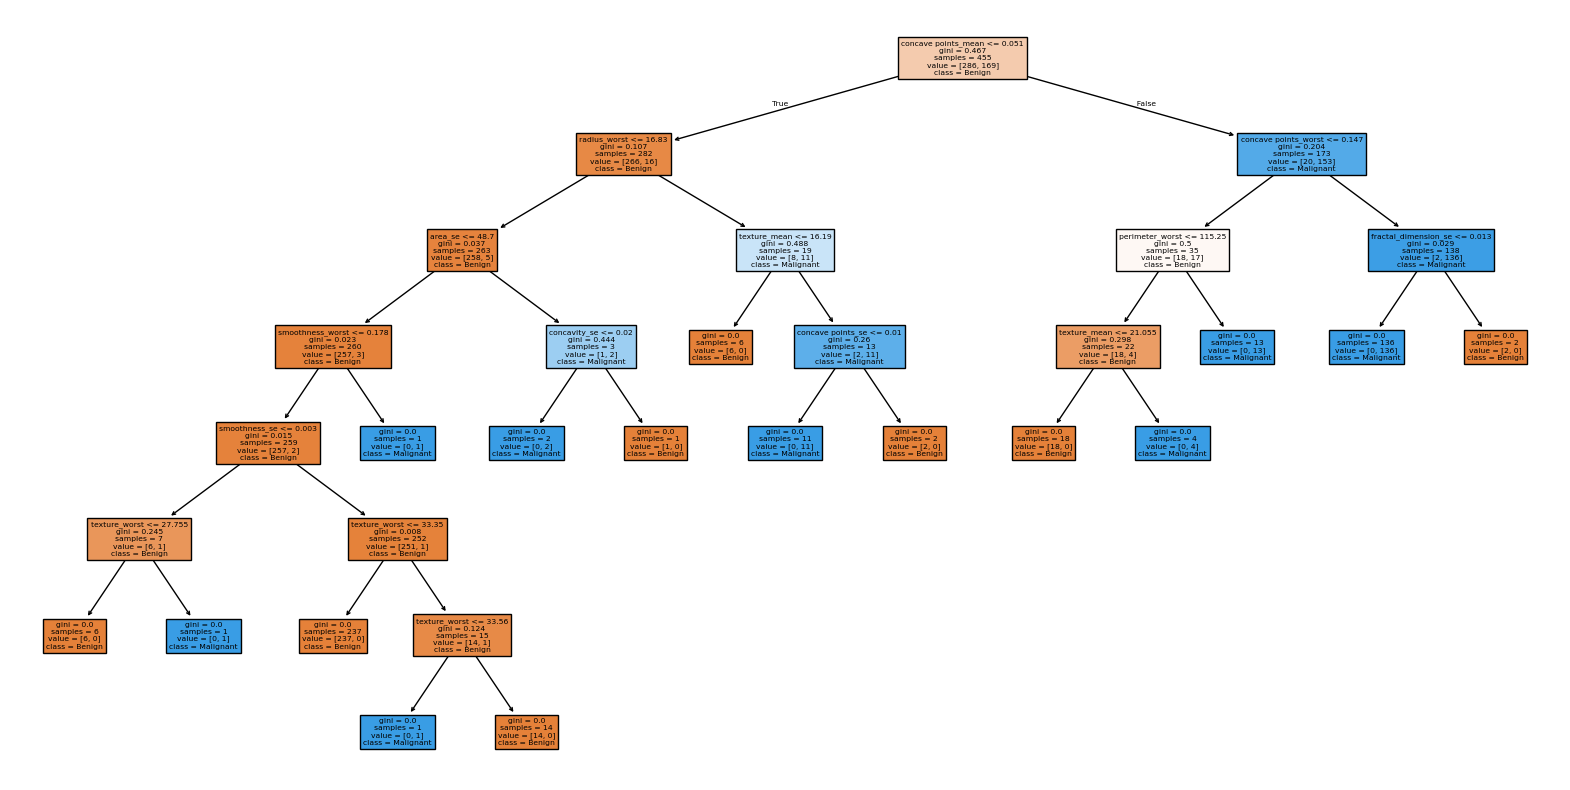

In [34]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["Benign", "Malignant"],
    filled=True
)

plt.show()


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
rf_pred = rf_model.predict(X_test)

print(rf_pred)

[0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1]


In [37]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Accuracy %:", rf_accuracy * 100)

Random Forest Accuracy: 0.9649122807017544
Accuracy %: 96.49122807017544


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, prediction in models.items():
    print("\n", name)
    print("Accuracy :", accuracy_score(y_test, prediction))
    print("Precision:", precision_score(y_test, prediction))
    print("Recall   :", recall_score(y_test, prediction))
    print("F1 Score :", f1_score(y_test, prediction))


 Logistic Regression
Accuracy : 0.956140350877193
Precision: 0.975
Recall   : 0.9069767441860465
F1 Score : 0.9397590361445783

 Decision Tree
Accuracy : 0.9473684210526315
Precision: 0.9302325581395349
Recall   : 0.9302325581395349
F1 Score : 0.9302325581395349

 Random Forest
Accuracy : 0.9649122807017544
Precision: 0.975609756097561
Recall   : 0.9302325581395349
F1 Score : 0.9523809523809523


In [39]:
results = []

for name, prediction in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.956140   0.975000  0.906977  0.939759
1        Decision Tree  0.947368   0.930233  0.930233  0.930233
2        Random Forest  0.964912   0.975610  0.930233  0.952381


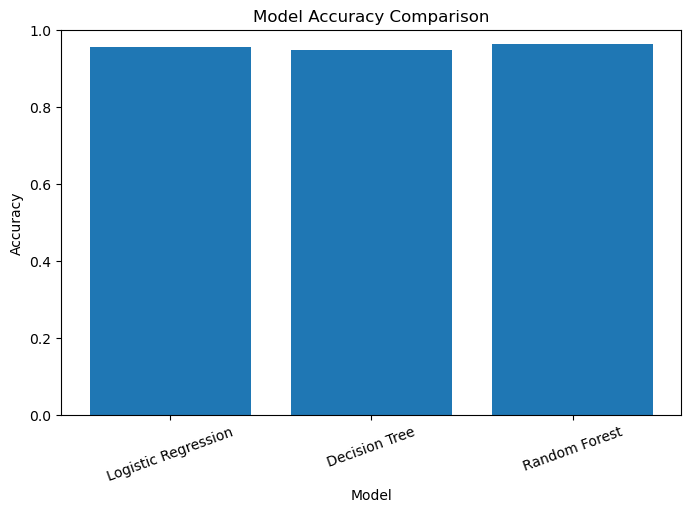

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

In [41]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

print(feature_importance)

                    Feature  Importance
0               radius_mean    0.048703
1              texture_mean    0.013591
2            perimeter_mean    0.053270
3                 area_mean    0.047555
4           smoothness_mean    0.007285
5          compactness_mean    0.013944
6            concavity_mean    0.068001
7       concave points_mean    0.106210
8             symmetry_mean    0.003770
9    fractal_dimension_mean    0.003886
10                radius_se    0.020139
11               texture_se    0.004724
12             perimeter_se    0.011303
13                  area_se    0.022407
14            smoothness_se    0.004271
15           compactness_se    0.005253
16             concavity_se    0.009386
17        concave points_se    0.003513
18              symmetry_se    0.004018
19     fractal_dimension_se    0.005321
20             radius_worst    0.077987
21            texture_worst    0.021749
22          perimeter_worst    0.067115
23               area_worst    0.153892


In [42]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                    Feature  Importance
23               area_worst    0.153892
27     concave points_worst    0.144663
7       concave points_mean    0.106210
20             radius_worst    0.077987
6            concavity_mean    0.068001
22          perimeter_worst    0.067115
2            perimeter_mean    0.053270
0               radius_mean    0.048703
3                 area_mean    0.047555
26          concavity_worst    0.031802
13                  area_se    0.022407
21            texture_worst    0.021749
25        compactness_worst    0.020266
10                radius_se    0.020139
5          compactness_mean    0.013944
1              texture_mean    0.013591
12             perimeter_se    0.011303
24         smoothness_worst    0.010644
28           symmetry_worst    0.010120
16             concavity_se    0.009386
4           smoothness_mean    0.007285
19     fractal_dimension_se    0.005321
15           compactness_se    0.005253
29  fractal_dimension_worst    0.005210


In [43]:
top10 = feature_importance.head(10)

print(top10)

                 Feature  Importance
23            area_worst    0.153892
27  concave points_worst    0.144663
7    concave points_mean    0.106210
20          radius_worst    0.077987
6         concavity_mean    0.068001
22       perimeter_worst    0.067115
2         perimeter_mean    0.053270
0            radius_mean    0.048703
3              area_mean    0.047555
26       concavity_worst    0.031802


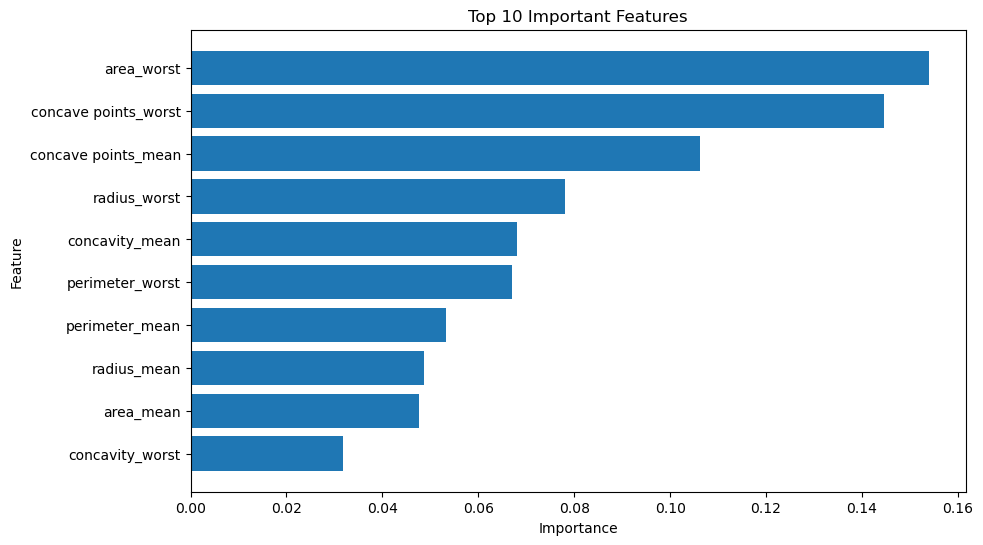

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [45]:
import joblib

joblib.dump(rf_model, "breast_cancer_model.pkl")

['breast_cancer_model.pkl']

In [46]:
rf_model_loaded = joblib.load("breast_cancer_model.pkl")

In [47]:
loaded_pred = rf_model_loaded.predict(X_test)

print("Accuracy:", accuracy_score(y_test, loaded_pred))

Accuracy: 0.9649122807017544


In [48]:
sample = X_test.iloc[0].values.reshape(1, -1)

print(sample)

[[1.247e+01 1.860e+01 8.109e+01 4.819e+02 9.965e-02 1.058e-01 8.005e-02
  3.821e-02 1.925e-01 6.373e-02 3.961e-01 1.044e+00 2.497e+00 3.029e+01
  6.953e-03 1.911e-02 2.701e-02 1.037e-02 1.782e-02 3.586e-03 1.497e+01
  2.464e+01 9.605e+01 6.779e+02 1.426e-01 2.378e-01 2.671e-01 1.015e-01
  3.014e-01 8.750e-02]]


In [49]:
prediction = rf_model.predict(sample)

print("Prediction:", prediction[0])

Prediction: 0


c:\Users\pawan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [50]:
if prediction[0] == 1:
    print("Prediction: Malignant")
else:
    print("Prediction: Benign")

Prediction: Benign


In [51]:
def predict_patient(patient_data):
    prediction = rf_model.predict([patient_data])

    if prediction[0] == 1:
        return "Malignant"
    else:
        return "Benign"

In [52]:
sample = X_test.iloc[0].tolist()

result = predict_patient(sample)

print("Prediction:", result)

Prediction: Benign


c:\Users\pawan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [53]:
probability = rf_model.predict_proba([sample])

print("Benign probability:", probability[0][0])
print("Malignant probability:", probability[0][1])

Benign probability: 0.97
Malignant probability: 0.03


c:\Users\pawan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(455, 30)
(114, 30)


In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

In [56]:
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [57]:
knn_pred = knn_model.predict(X_test_scaled)

print(knn_pred)

[0 1 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1]


c:\Users\pawan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\pawan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\pawan\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pawan\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [58]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)
print("Accuracy %:", knn_accuracy * 100)

KNN Accuracy: 0.9473684210526315
Accuracy %: 94.73684210526315


In [59]:
from sklearn.metrics import confusion_matrix

knn_cm = confusion_matrix(y_test, knn_pred)

print(knn_cm)

[[68  3]
 [ 3 40]]


In [60]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    knn_pred,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        71
   Malignant       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [61]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)
    accuracies.append(accuracy)

print(accuracies)

[0.9385964912280702, 0.9473684210526315, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9649122807017544, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315]


In [62]:
for k, accuracy in zip(k_values, accuracies):
    print("K =", k, "Accuracy =", accuracy)

K = 1 Accuracy = 0.9385964912280702
K = 2 Accuracy = 0.9473684210526315
K = 3 Accuracy = 0.9473684210526315
K = 4 Accuracy = 0.956140350877193
K = 5 Accuracy = 0.9473684210526315
K = 6 Accuracy = 0.956140350877193
K = 7 Accuracy = 0.9473684210526315
K = 8 Accuracy = 0.956140350877193
K = 9 Accuracy = 0.9649122807017544
K = 10 Accuracy = 0.956140350877193
K = 11 Accuracy = 0.956140350877193
K = 12 Accuracy = 0.956140350877193
K = 13 Accuracy = 0.956140350877193
K = 14 Accuracy = 0.956140350877193
K = 15 Accuracy = 0.956140350877193
K = 16 Accuracy = 0.9473684210526315
K = 17 Accuracy = 0.9473684210526315
K = 18 Accuracy = 0.9473684210526315
K = 19 Accuracy = 0.9473684210526315
K = 20 Accuracy = 0.9473684210526315


In [63]:
best_k = k_values[accuracies.index(max(accuracies))]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 9
Best Accuracy: 0.9649122807017544


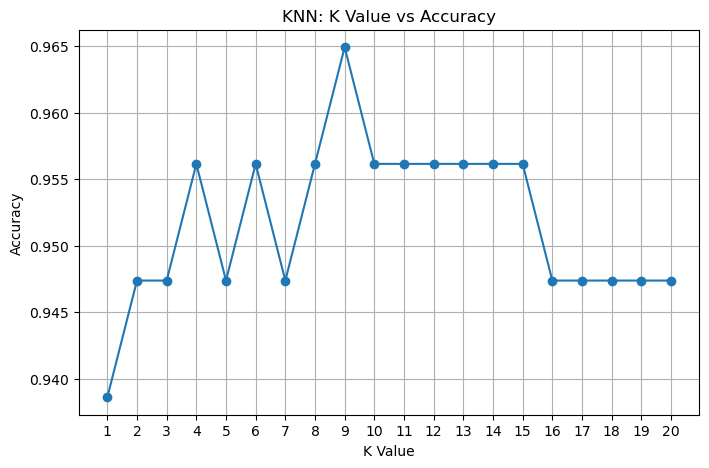

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [65]:
print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 9
Best Accuracy: 0.9649122807017544


In [66]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_scaled, y_train)

final_knn_pred = final_knn.predict(X_test_scaled)

print("Final KNN Accuracy:",
      accuracy_score(y_test, final_knn_pred))

Final KNN Accuracy: 0.9649122807017544


In [67]:
from sklearn.svm import SVC

NameError: name 'svm_model' is not defined